## 1. Imports & Installation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)
from imblearn.over_sampling import ADASYN

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans'
})
PALETTE  = ['#4361EE', '#F72585', '#7209B7', '#3A0CA3', '#4CC9F0']
C_BEFORE = '#B5B5B5'
C_AFTER  = '#4361EE'

In [3]:
from pathlib import Path
import warnings

### Data Preparation

In [5]:
data_path = Path('dm2_25_26_dataset_tabular/DM2_project/cmi_internet.csv')

In [7]:
df_orig = pd.read_csv(data_path)
df_original = df_orig.copy()

In [9]:
df = pd.read_csv("cmi_internet_copie_2.csv")
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,FGC-FGC_CU,FGC-FGC_CU_Zone,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,Season
0,5.0,0.0,51.00,26.000,66.55,88.2,114.0,5.0,0.0,0.0,...,1.0,19.541300,32.690900,79.9,3.0,6.5,20.6250,2.01,448.0,0
1,9.0,0.0,62.55,22.000,75.00,70.0,122.0,5.0,3.0,0.0,...,1.0,15.410700,27.055200,64.0,0.0,11.0,20.6250,2.01,406.0,2
2,10.0,1.0,71.00,25.575,65.00,94.0,117.0,5.0,20.0,1.0,...,1.9,27.415100,44.987000,54.0,2.0,10.0,12.4500,2.01,453.0,2
3,9.0,0.0,71.00,26.000,60.00,97.0,117.0,6.0,18.0,1.0,...,2.0,26.479800,45.996600,45.0,0.0,7.0,20.6250,2.01,577.0,3
4,18.0,1.0,65.00,26.000,68.00,81.0,114.0,5.0,9.0,0.0,...,2.0,39.098464,46.192299,55.1,1.0,9.0,19.9825,1.04,445.0,1


In [11]:
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (8301, 31)
Shape y: (8301,)


### Data Partitioning

In [11]:
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100)

In [15]:
from sklearn.preprocessing import StandardScaler

In [17]:
scl = StandardScaler()
X_train = scl.fit_transform(X_train)
X_test = scl.transform(X_test)

### Balance classes

In [10]:
# ADASYN - Adaptive Synthetic Sampling Approach for Imbalanced Learning
from imblearn.over_sampling import ADASYN
from collections import Counter

print("Distribuzione PRIMA:", Counter(y_train))

adasyn = ADASYN(
    sampling_strategy='not majority', # ricampionare tutte le classi tranne quella maggioritaria.
    random_state=42,
    n_neighbors=5
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_train, y_train)

print("Distribuzione DOPO: ", Counter(y_train_bal))

Distribuzione PRIMA: Counter({0.0: 3968, 1.0: 1121, 2.0: 658, 3.0: 63})
Distribuzione DOPO:  Counter({2.0: 4160, 1.0: 4124, 3.0: 3980, 0.0: 3968})


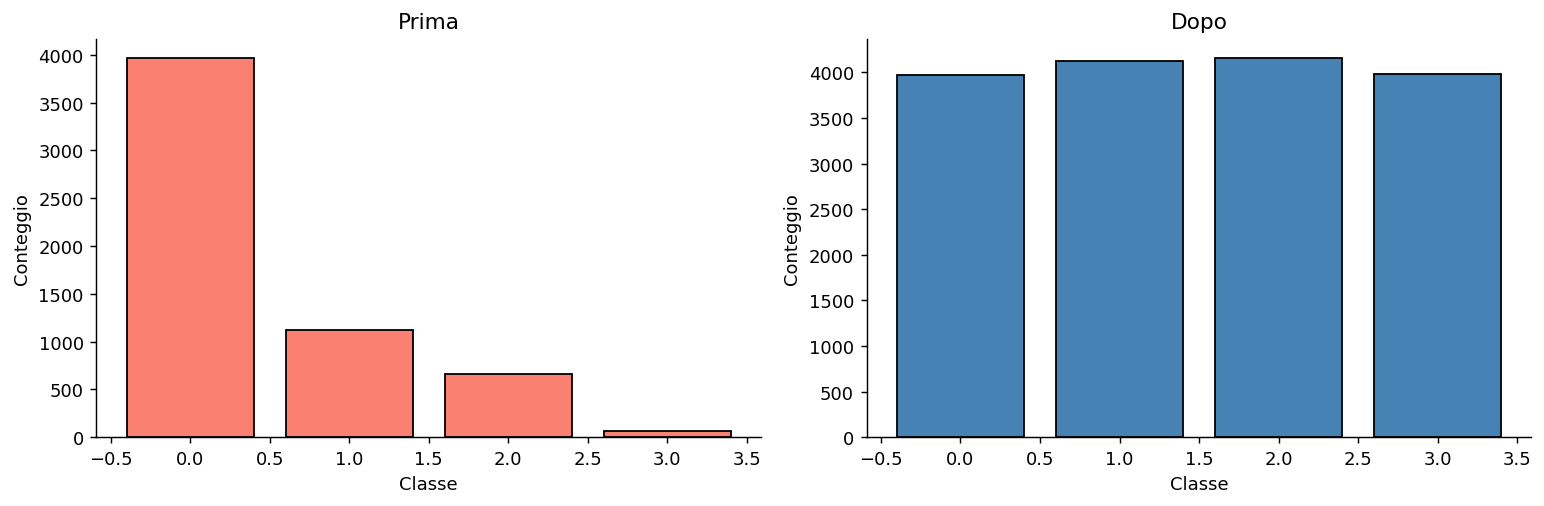

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = Counter(y_train)
after  = Counter(y_train_bal)

axes[0].bar(before.keys(), before.values(), color='salmon', edgecolor='black')
axes[0].set_title('Prima')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Conteggio')

axes[1].bar(after.keys(), after.values(), color='steelblue', edgecolor='black')
axes[1].set_title('Dopo')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Conteggio')

plt.tight_layout()
plt.show()

### Sklearn Multilayer Perceptron

In [12]:
from sklearn.neural_network import MLPClassifier
hidden_layer_sizes = (100, 200,)

In [13]:
clf = MLPClassifier(random_state=0)

clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.4263348052990767
F1-score [0.58951533 0.21428571 0.125      0.02597403]
              precision    recall  f1-score   support

         0.0       0.70      0.51      0.59      1751
         1.0       0.18      0.27      0.21       440
         2.0       0.10      0.17      0.12       277
         3.0       0.02      0.04      0.03        23

    accuracy                           0.43      2491
   macro avg       0.25      0.25      0.24      2491
weighted avg       0.53      0.43      0.47      2491



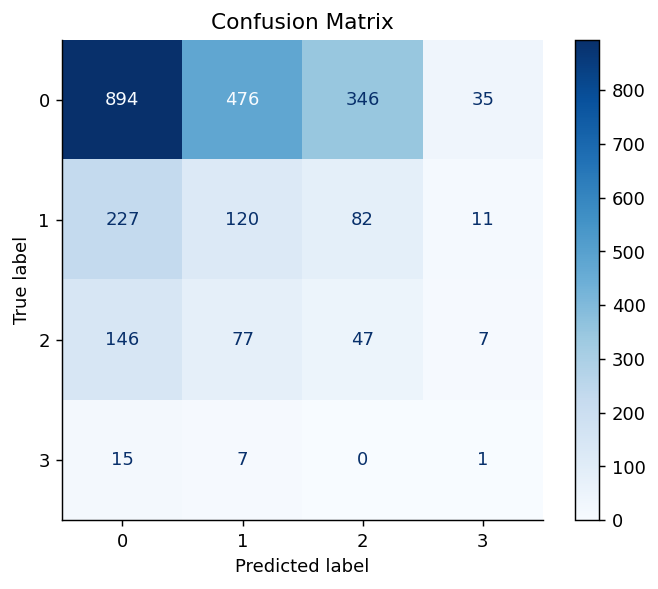

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

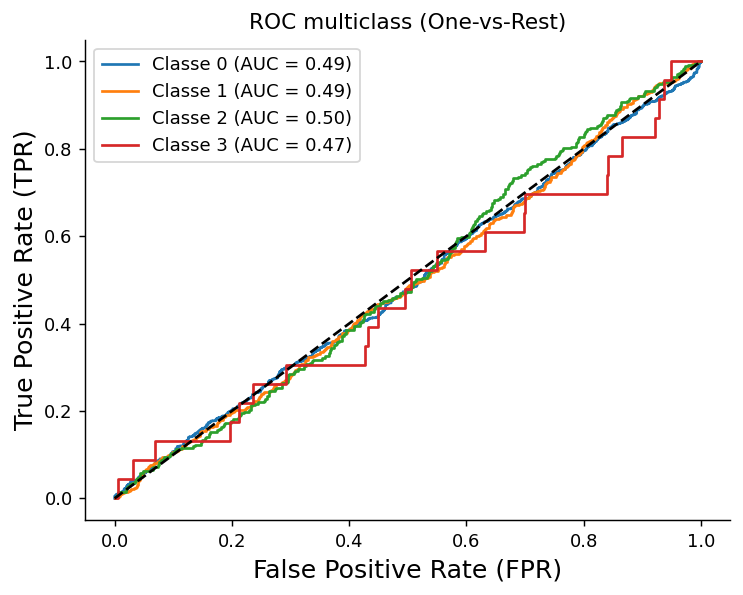

In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

# y_test contient des classes comme: [0,1,2,3]
classes = [0.0, 1.0, 2.0, 3.0]
y_test_bin = label_binarize(y_test, classes=classes)

y_scores = clf.predict_proba(X_test)  # shape = (n_samples, 4)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {i} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title("ROC multiclass (One-vs-Rest)")
plt.legend()
plt.show()

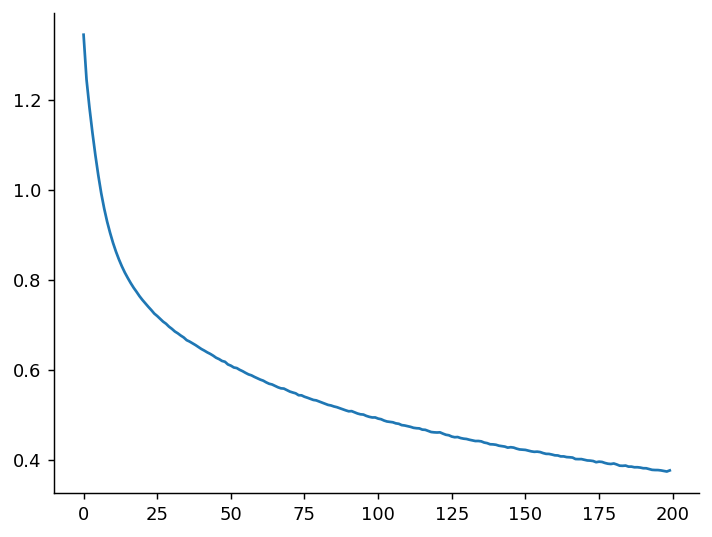

In [17]:
plt.plot(clf.loss_curve_)
plt.show()

**Smote**

In [19]:
# SMOTE - Synthetic Minority Over-sampling Technique
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [19]:
clf = MLPClassifier(random_state=0)

clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.4367723805700522
F1-score [0.59687906 0.2110009  0.14088398 0.05479452]
              precision    recall  f1-score   support

         0.0       0.69      0.52      0.60      1751
         1.0       0.17      0.27      0.21       440
         2.0       0.11      0.18      0.14       277
         3.0       0.04      0.09      0.05        23

    accuracy                           0.44      2491
   macro avg       0.26      0.27      0.25      2491
weighted avg       0.53      0.44      0.47      2491



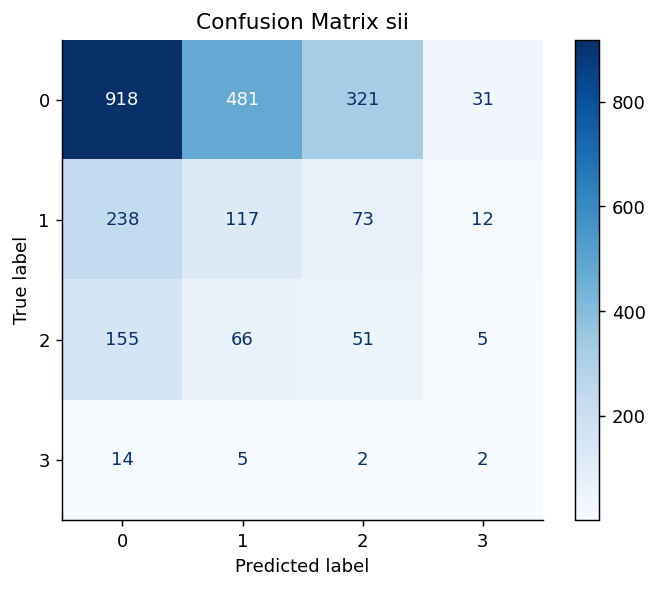

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix sii")
plt.show()


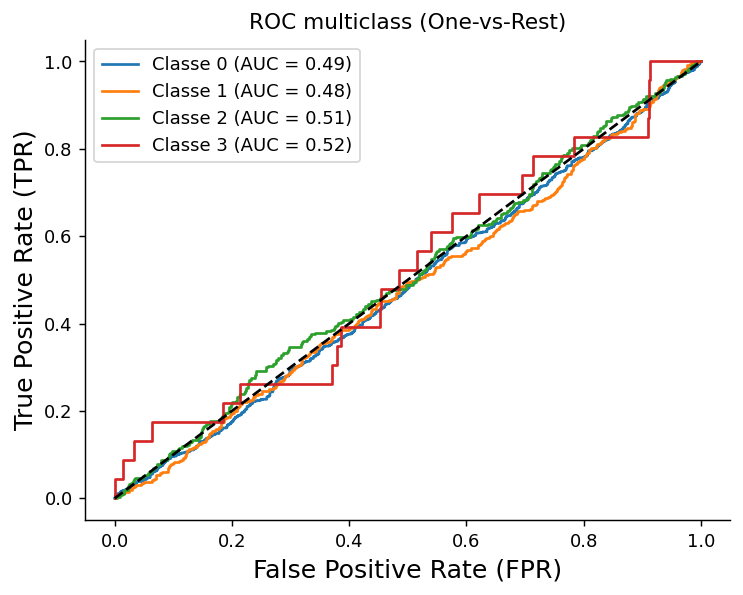

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize

# y_test contient des classes comme: [0,1,2,3]
classes = [0.0, 1.0, 2.0, 3.0]
y_test_bin = label_binarize(y_test, classes=classes)

y_scores = clf.predict_proba(X_test)  # shape = (n_samples, 4)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_scores[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Classe {i} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate (FPR)', fontsize=14)
plt.ylabel('True Positive Rate (TPR)', fontsize=14)
plt.title("ROC multiclass (One-vs-Rest)")
plt.legend()
plt.show()

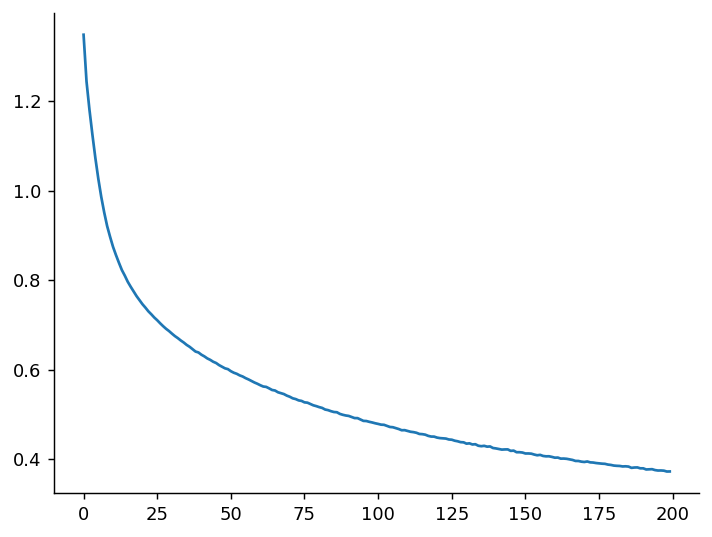

In [22]:
plt.plot(clf.loss_curve_)
plt.show()

In [23]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1,
                    learning_rate='adaptive',
                    activation='tanh', early_stopping=False,
                    momentum=0.9, random_state=0, max_iter=500)

clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.502207948615014
F1-score [0.66946863 0.20653319 0.11575563 0.05      ]
              precision    recall  f1-score   support

         0.0       0.71      0.64      0.67      1751
         1.0       0.19      0.22      0.21       440
         2.0       0.10      0.13      0.12       277
         3.0       0.04      0.09      0.05        23

    accuracy                           0.50      2491
   macro avg       0.26      0.27      0.26      2491
weighted avg       0.54      0.50      0.52      2491



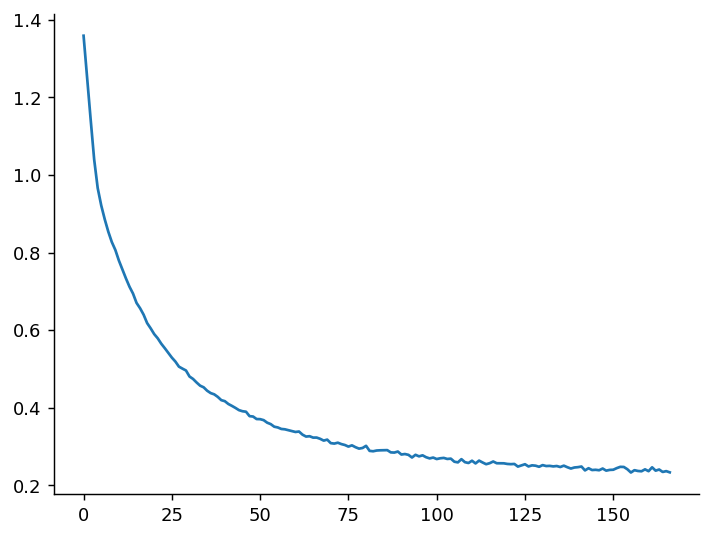

In [24]:
plt.plot(clf.loss_curve_)
plt.show()

In [26]:
clf = MLPClassifier(hidden_layer_sizes=(128, 64, 32,), alpha=0.1, learning_rate='adaptive',
                    activation='tanh', early_stopping=True, momentum=0.9, random_state=0)

clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.4704937775993577
F1-score [0.63863988 0.2028436  0.10197368 0.02380952]
              precision    recall  f1-score   support

         0.0       0.70      0.59      0.64      1751
         1.0       0.17      0.24      0.20       440
         2.0       0.09      0.11      0.10       277
         3.0       0.02      0.04      0.02        23

    accuracy                           0.47      2491
   macro avg       0.25      0.25      0.24      2491
weighted avg       0.53      0.47      0.50      2491



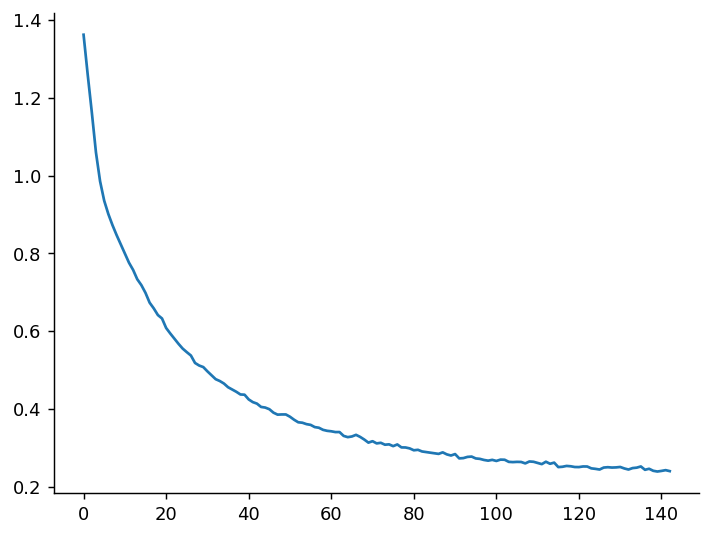

In [27]:
plt.plot(clf.loss_curve_)
plt.show()

### New target variable data preparation 

**Basic_Demos-Sex**

In [24]:
df['sii']=df_orig.loc[df.index, 'sii']
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Max_Stage,FGC-FGC_CU,FGC-FGC_CU_Zone,...,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec,Season,sii
0,5.0,0.0,51.00,26.000,66.55,88.2,114.0,5.0,0.0,0.0,...,19.541300,32.690900,79.9,3.0,6.5,20.6250,2.01,448.0,0,2.0
1,9.0,0.0,62.55,22.000,75.00,70.0,122.0,5.0,3.0,0.0,...,15.410700,27.055200,64.0,0.0,11.0,20.6250,2.01,406.0,2,0.0
2,10.0,1.0,71.00,25.575,65.00,94.0,117.0,5.0,20.0,1.0,...,27.415100,44.987000,54.0,2.0,10.0,12.4500,2.01,453.0,2,0.0
3,9.0,0.0,71.00,26.000,60.00,97.0,117.0,6.0,18.0,1.0,...,26.479800,45.996600,45.0,0.0,7.0,20.6250,2.01,577.0,3,1.0
4,18.0,1.0,65.00,26.000,68.00,81.0,114.0,5.0,9.0,0.0,...,39.098464,46.192299,55.1,1.0,9.0,19.9825,1.04,445.0,1,0.0


In [25]:
df_NN = df.copy()

In [26]:
df.drop(columns=['Basic_Demos-Sex'], inplace=True)

In [27]:
X = df.values
y = np.array(df_NN['Basic_Demos-Sex'])

In [28]:
print("Distribuzione classi:", Counter(y))

Distribuzione classi: Counter({0.0: 4947, 1.0: 3354})


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [30]:
print("Distribution first:", Counter(y_train))

adasyn = ADASYN(
    sampling_strategy='minority',
    random_state=42,
    n_neighbors=5
)

X_train_bal, y_train_bal = adasyn.fit_resample(X_train, y_train)

print("Distribution after: ", Counter(y_train_bal))

Distribution first: Counter({0.0: 3462, 1.0: 2348})
Distribution after:  Counter({1.0: 3654, 0.0: 3462})


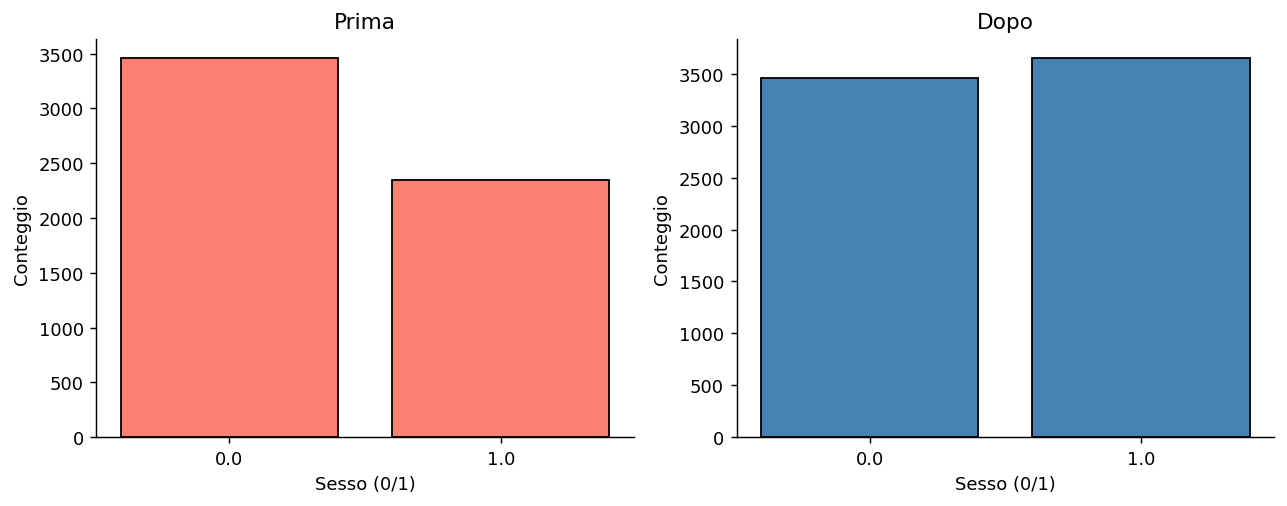

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

before = Counter(y_train)
after  = Counter(y_train_bal)

axes[0].bar([str(k) for k in before.keys()], before.values(), color='salmon', edgecolor='black')
axes[0].set_title('Prima')
axes[0].set_xlabel('Sesso (0/1)')
axes[0].set_ylabel('Conteggio')

axes[1].bar([str(k) for k in after.keys()], after.values(), color='steelblue', edgecolor='black')
axes[1].set_title('Dopo')
axes[1].set_xlabel('Sesso (0/1)')
axes[1].set_ylabel('Conteggio')

plt.tight_layout()
plt.show()

In [32]:
clf = MLPClassifier(random_state=0)

clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6134082697711762
F1-score [0.64214047 0.57965954]
              precision    recall  f1-score   support

         0.0       0.72      0.58      0.64      1485
         1.0       0.52      0.66      0.58      1006

    accuracy                           0.61      2491
   macro avg       0.62      0.62      0.61      2491
weighted avg       0.64      0.61      0.62      2491



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [33]:
# SMOTE - Synthetic Minority Over-sampling Technique
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [34]:
clf = MLPClassifier(random_state=0)

clf.fit(X_train_bal, y_train_bal)

y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.6435166599759133
F1-score [0.75671233 0.33333333]
              precision    recall  f1-score   support

         0.0       0.64      0.93      0.76      1485
         1.0       0.68      0.22      0.33      1006

    accuracy                           0.64      2491
   macro avg       0.66      0.58      0.55      2491
weighted avg       0.66      0.64      0.59      2491



### Keras

In [ ]:
!pip install scikeras

In [ ]:
!pip install tensorflow

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [23]:
from scikeras.wrappers import KerasClassifier

In [25]:
n_classes = 4
def build_model():

    n_feature = X_train_bal.shape[1]
    model = Sequential()
    model.add(Dense(128, input_dim=n_feature, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer="adam", metrics=['accuracy'])
    return model

In [27]:
model1 = build_model()
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,612 (49.27 KB)

 Trainable params: 12,612 (49.27 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history1 = model1.fit(X_train_bal, y_train_bal, epochs=200, batch_size=32).history

Epoch 1/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4670 - loss: 1.1500
Epoch 2/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6093 - loss: 0.8515
Epoch 3/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6591 - loss: 0.7453
Epoch 4/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6995 - loss: 0.6792
Epoch 5/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7268 - loss: 0.6269
Epoch 6/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7514 - loss: 0.5821
Epoch 7/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7741 - loss: 0.5362
Epoch 8/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7908 - loss: 0.5001
Epoch 9/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8019 - loss: 0.4747
Epoch 10/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8181 - loss: 0.4393
Epoch 11/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8334 - loss: 0.4122
Epoch 12/200
496/496 ━━━━━━━━━━━━━━━━━━━━

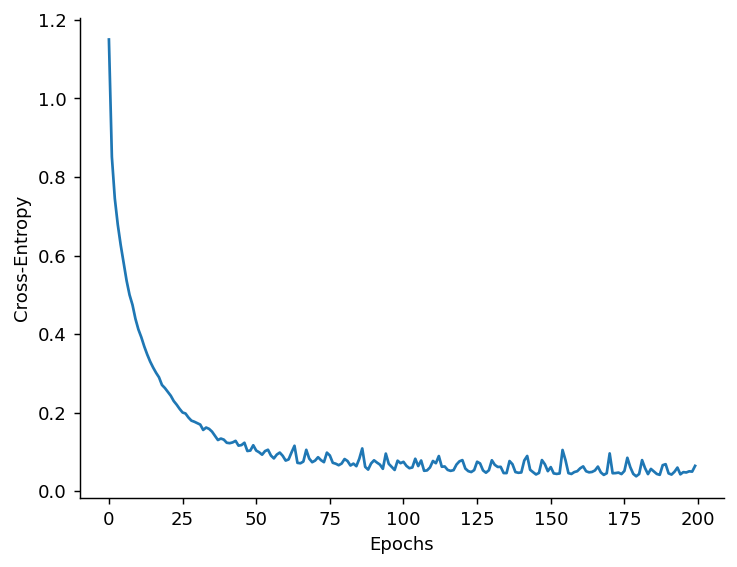

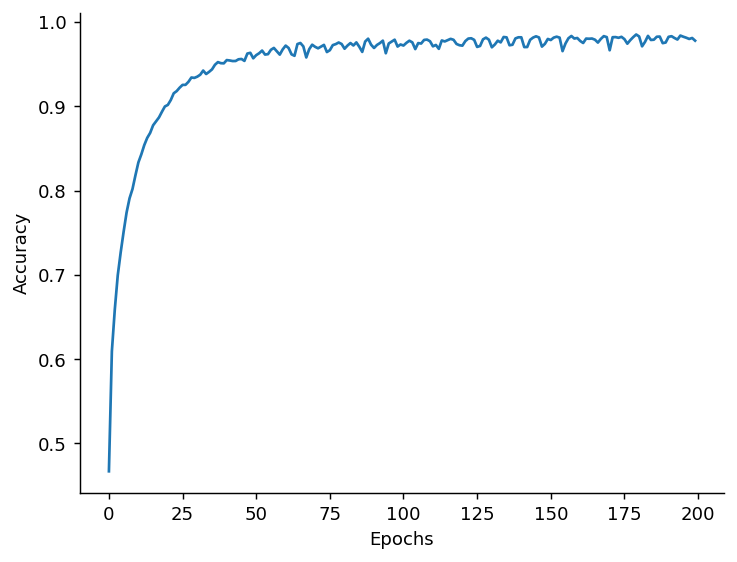

In [31]:
plt.plot(history1['loss'])
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.show()
plt.plot(history1['accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

In [33]:
test_loss_1, test_acc_1 = model1.evaluate(X_test, y_test)
print('Loss %f, Accuracy %f' % (test_loss_1, test_acc_1))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5383 - loss: 8.2662
Loss 8.266170, Accuracy 0.538338


### Sklearn Wrapper
wraps a keras model in a sklearn-like object

In [35]:
clf = KerasClassifier(build_fn=build_model)

In [37]:
clf.fit(X_train_bal, y_train_bal, epochs=200)

Epoch 1/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4849 - loss: 1.1277
Epoch 2/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6076 - loss: 0.8510
Epoch 3/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6597 - loss: 0.7468
Epoch 4/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6976 - loss: 0.6826
Epoch 5/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7283 - loss: 0.6299
Epoch 6/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7472 - loss: 0.5868
Epoch 7/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7684 - loss: 0.5458
Epoch 8/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7879 - loss: 0.5072
Epoch 9/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8015 - loss: 0.4812
Epoch 10/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8180 - loss: 0.4482
Epoch 11/200
496/496 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8271 - loss: 0.4260
Epoch 12/200
496/496 ━━━━━━━━━━━━━━━━━━━━

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x00000253710B2A20>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [39]:
clf.model_.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,838 (147.81 KB)

 Trainable params: 12,612 (49.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,226 (98.54 KB)

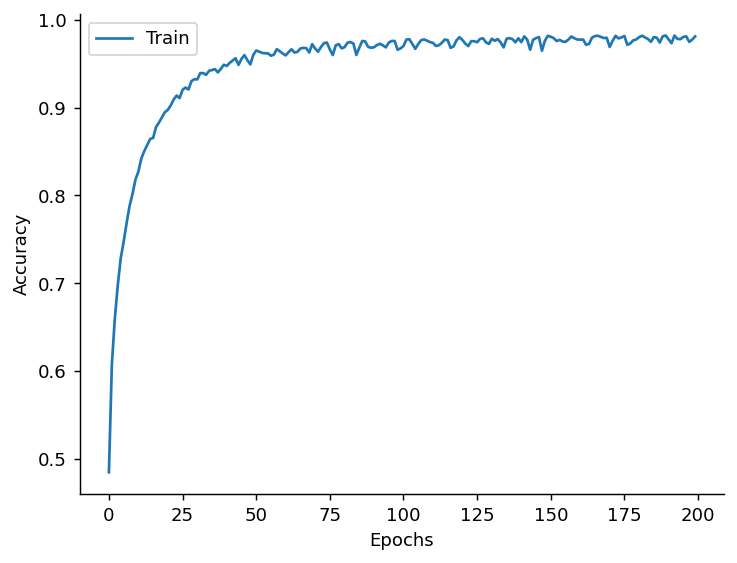

In [41]:
history = clf.history_
plt.plot(history['accuracy'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

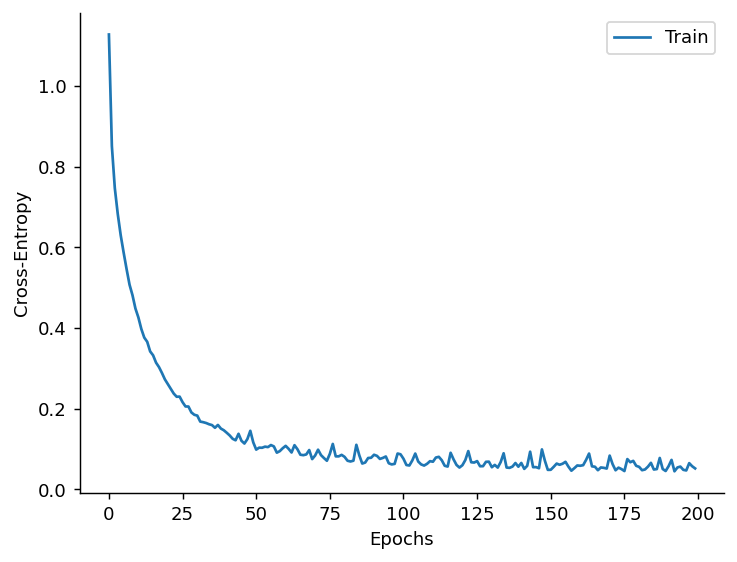

In [43]:
plt.plot(history['loss'], label='Train')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

In [45]:
y_pred = clf.predict(X_test).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.5335206744279406
F1-score [0.69680392 0.18348624 0.11789474 0.03773585]
              precision    recall  f1-score   support

         0.0       0.70      0.69      0.70      1751
         1.0       0.17      0.20      0.18       440
         2.0       0.14      0.10      0.12       277
         3.0       0.03      0.04      0.04        23

    accuracy                           0.53      2491
   macro avg       0.26      0.26      0.26      2491
weighted avg       0.54      0.53      0.54      2491



In [47]:
clf = KerasClassifier(build_fn=build_model)

In [49]:
clf.fit(X_train_bal, y_train_bal, validation_split=0.2, epochs=1000)

Epoch 1/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4006 - loss: 1.2135 - val_accuracy: 0.0668 - val_loss: 1.9920
Epoch 2/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5019 - loss: 1.0843 - val_accuracy: 0.4324 - val_loss: 1.4696
Epoch 3/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5684 - loss: 0.9743 - val_accuracy: 0.6699 - val_loss: 1.0337
Epoch 4/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6194 - loss: 0.8780 - val_accuracy: 0.7569 - val_loss: 0.7432
Epoch 5/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6613 - loss: 0.7977 - val_accuracy: 0.8731 - val_loss: 0.5271
Epoch 6/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7010 - loss: 0.7313 - val_accuracy: 0.8835 - val_loss: 0.4486
Epoch 7/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7243 - loss: 0.6782 - val_accuracy: 0.9496 - val_loss: 0.2809
Epoch 8/1000
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7467 - loss: 0.6275 - 

KerasClassifier(
	model=None
	build_fn=<function build_model at 0x00000253710B2A20>
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [51]:
y_pred = clf.predict(X_test).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.5431553592934565
F1-score [0.71098592 0.14303329 0.11498258 0.        ]
              precision    recall  f1-score   support

         0.0       0.70      0.72      0.71      1751
         1.0       0.16      0.13      0.14       440
         2.0       0.11      0.12      0.11       277
         3.0       0.00      0.00      0.00        23

    accuracy                           0.54      2491
   macro avg       0.24      0.24      0.24      2491
weighted avg       0.53      0.54      0.54      2491



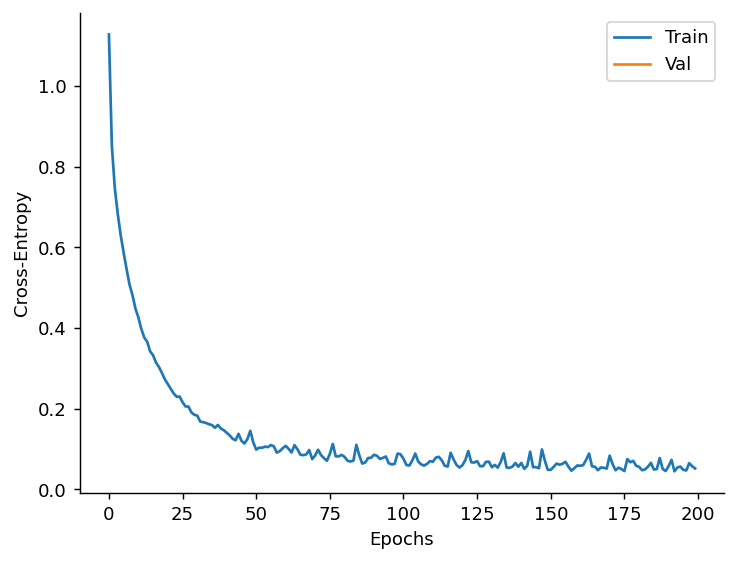

In [53]:
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

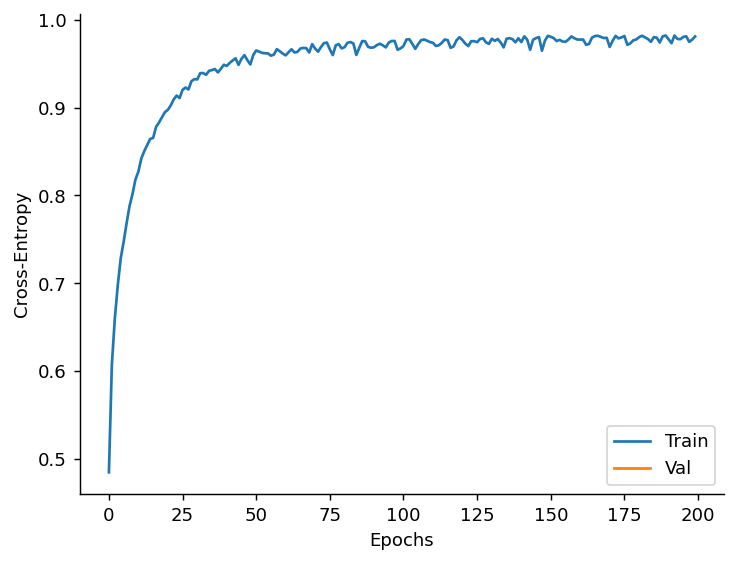

In [55]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

### Early stopping

In [68]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [70]:
es = EarlyStopping(monitor='val_accuracy', patience=50, verbose=True)
mc = ModelCheckpoint('best_model_NOREG.keras', monitor='val_accuracy', save_best_only=True)

clf = KerasClassifier(build_model, callbacks=[es, mc])

In [72]:
clf.fit(X_train_bal, y_train_bal, validation_split=0.2, epochs=500)

Epoch 1/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4003 - loss: 1.2098 - val_accuracy: 0.1433 - val_loss: 1.8668
Epoch 2/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5011 - loss: 1.0833 - val_accuracy: 0.3594 - val_loss: 1.5988
Epoch 3/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5783 - loss: 0.9700 - val_accuracy: 0.7024 - val_loss: 0.9703
Epoch 4/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6326 - loss: 0.8726 - val_accuracy: 0.8252 - val_loss: 0.6610
Epoch 5/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6700 - loss: 0.7945 - val_accuracy: 0.8819 - val_loss: 0.5252
Epoch 6/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7011 - loss: 0.7290 - val_accuracy: 0.9250 - val_loss: 0.3640
Epoch 7/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7261 - loss: 0.6762 - val_accuracy: 0.9276 - val_loss: 0.3110
Epoch 8/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7536 - loss: 0.6290 - val_accu

KerasClassifier(
	model=<function build_model at 0x000001D5E55222A0>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000001D5EC06DB80>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x000001D5EC06EFC0>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

In [74]:
y_pred = clf.predict(X_test).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy 0.5118426334805299
F1-score [0.67110842 0.23698384 0.12806026 0.05714286]
              precision    recall  f1-score   support

         0.0       0.71      0.63      0.67      1751
         1.0       0.20      0.30      0.24       440
         2.0       0.13      0.12      0.13       277
         3.0       0.08      0.04      0.06        23

    accuracy                           0.51      2491
   macro avg       0.28      0.27      0.27      2491
weighted avg       0.55      0.51      0.53      2491



In [76]:
y_pred = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy 0.5118426334805299
F1-score [0.67110842 0.23698384 0.12806026 0.05714286]
              precision    recall  f1-score   support

         0.0       0.71      0.63      0.67      1751
         1.0       0.20      0.30      0.24       440
         2.0       0.13      0.12      0.13       277
         3.0       0.08      0.04      0.06        23

    accuracy                           0.51      2491
   macro avg       0.28      0.27      0.27      2491
weighted avg       0.55      0.51      0.53      2491



### L2 Regularization

In [79]:
from keras.regularizers import l2, l1

def build_L2_model():
    model = Sequential()

    n_feature = X_train.shape[1]
    h_dim=100
    model.add(Dense(h_dim, activation='relu',
                    input_shape=(n_feature,), kernel_regularizer=l2(0.001)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(n_classes))

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [83]:
mc = ModelCheckpoint('best_model_L2.keras', monitor='val_accuracy', save_best_only=True)

L2_model = KerasClassifier(build_L2_model, callbacks=[es,mc])
L2_model.fit(X_train_bal, y_train_bal, validation_split=0.2, epochs=500)

Epoch 1/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3530 - loss: 1.6628 - val_accuracy: 0.0334 - val_loss: 5.4974
Epoch 2/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3624 - loss: 1.3583 - val_accuracy: 0.1704 - val_loss: 3.2861
Epoch 3/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3880 - loss: 1.2850 - val_accuracy: 0.1046 - val_loss: 5.5223
Epoch 4/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3977 - loss: 1.2607 - val_accuracy: 0.3471 - val_loss: 2.3231
Epoch 5/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3995 - loss: 1.2091 - val_accuracy: 0.1074 - val_loss: 2.1868
Epoch 6/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3523 - loss: 1.1986 - val_accuracy: 0.2778 - val_loss: 2.4586
Epoch 7/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3843 - loss: 1.1824 - val_accuracy: 0.5424 - val_loss: 1.5230
Epoch 8/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4593 - loss: 1.1415 - val_accu

KerasClassifier(
	model=<function build_L2_model at 0x000001D5EBDE7560>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000001D5EC06DB80>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x000001D5D9445220>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

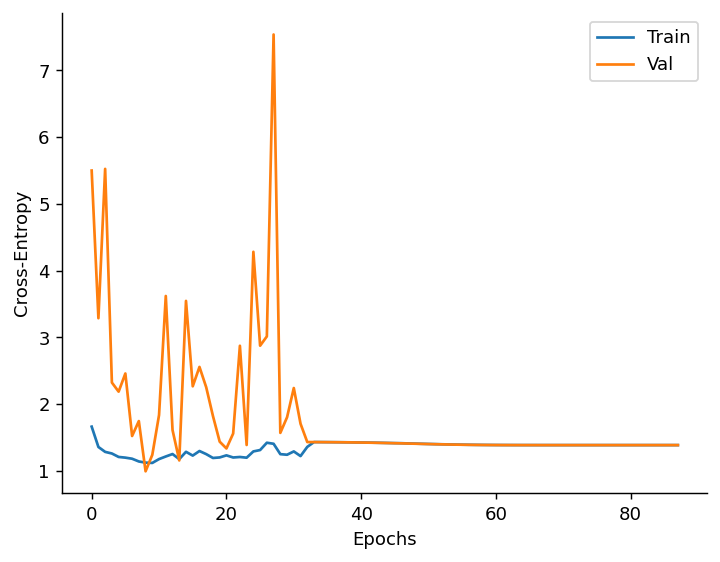

In [87]:
history = L2_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

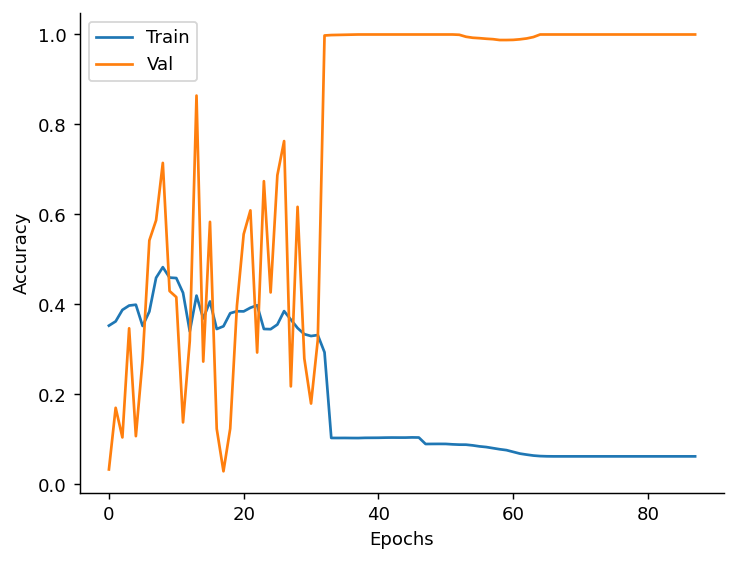

In [89]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Dropout

In [92]:
from keras.layers import Dropout

def build_DROPOUT_model():
    # define the model
    model = Sequential()

    n_feature = X_train.shape[1]
    h_dim=100
    model.add(Dense(h_dim, activation='relu', input_shape=(n_feature,)))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dense(h_dim, activation='relu'))
    model.add(Dropout(0.1))
    model.add(Dense(h_dim, activation='relu'))
    #linear activation
    model.add(Dense(n_classes))

    #compile the model
    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

In [94]:
mc = ModelCheckpoint('best_model_DROPOUT.keras', monitor='val_accuracy', save_best_only=True)

DROPOUT_model = KerasClassifier(build_DROPOUT_model, callbacks=[es,mc])
DROPOUT_model.fit(X_train_bal, y_train_bal, validation_split=0.2, epochs=500)

Epoch 1/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3524 - loss: 1.4290 - val_accuracy: 0.0217 - val_loss: 4.8303
Epoch 2/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4407 - loss: 1.2314 - val_accuracy: 0.2016 - val_loss: 2.9612
Epoch 3/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4748 - loss: 1.1696 - val_accuracy: 0.7386 - val_loss: 1.9570
Epoch 4/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4798 - loss: 1.1355 - val_accuracy: 0.8224 - val_loss: 1.7343
Epoch 5/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5026 - loss: 1.0906 - val_accuracy: 0.8220 - val_loss: 1.0731
Epoch 6/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4468 - loss: 1.1480 - val_accuracy: 0.1439 - val_loss: 2.7283
Epoch 7/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4501 - loss: 1.1160 - val_accuracy: 0.5937 - val_loss: 1.3036
Epoch 8/500
397/397 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4251 - loss: 1.1744 - val_accu

KerasClassifier(
	model=<function build_DROPOUT_model at 0x000001D5EBDE4E00>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=1
	callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x000001D5EC06DB80>, <keras.src.callbacks.model_checkpoint.ModelCheckpoint object at 0x000001D5EBDF4710>]
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)

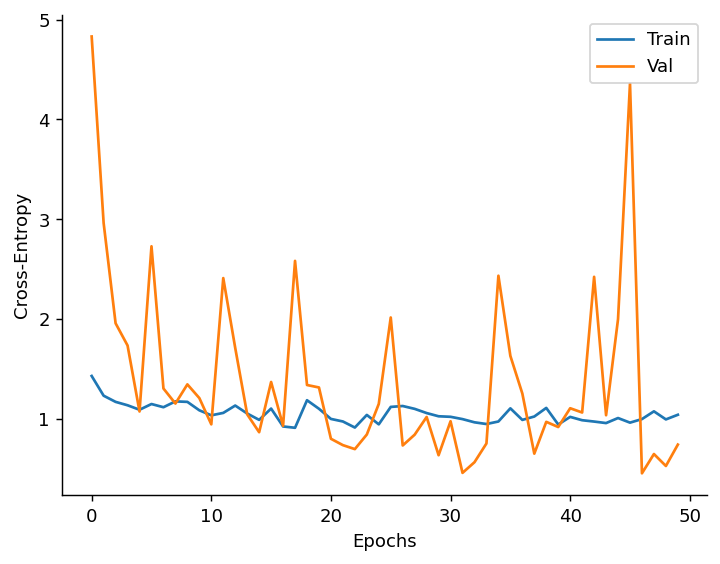

In [96]:
history = DROPOUT_model.history_
plt.plot(history['loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy')
plt.legend()
plt.show()

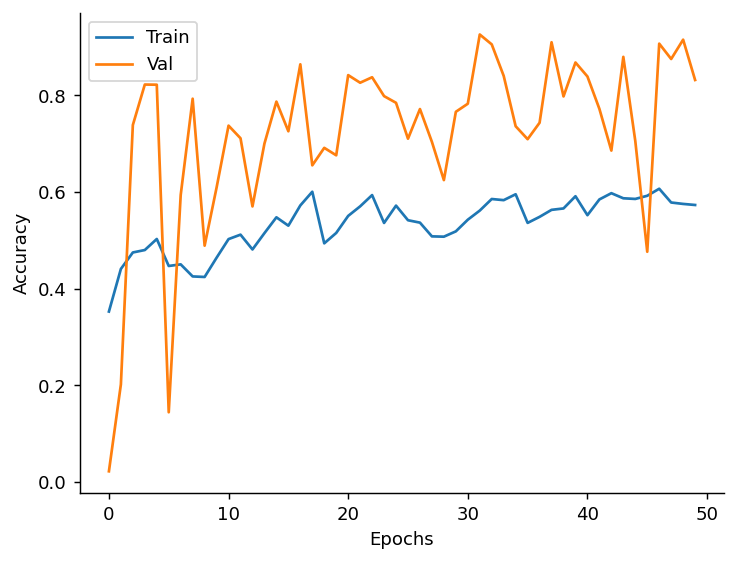

In [98]:
plt.plot(history['accuracy'], label='Train')
plt.plot(history['val_accuracy'], label='Val')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#### Model Comparison

In [104]:
# laod best models and test them
from keras.models import load_model

best_NOREG_model = load_model('best_model_NOREG.keras')
best_L2_model = load_model('best_model_L2.keras')
best_DROPOUT_model = load_model('best_model_DROPOUT.keras')

loss_NOREG, acc_NOREG = best_NOREG_model.evaluate(X_test, y_test)
loss_L2, acc_L2 = best_L2_model.evaluate(X_test, y_test)
loss_DROPOUT, acc_DROPOUT = best_DROPOUT_model.evaluate(X_test, y_test)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5725 - loss: 4.2196
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0996 - loss: 1.4287
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2947 - loss: 2.1302


In [106]:
print('Loss %f, Accuracy %f' % (loss_NOREG, acc_NOREG))
print('Loss %f, Accuracy %f' % (loss_L2, acc_L2))
print('Loss %f, Accuracy %f' % (loss_DROPOUT, acc_DROPOUT))

Loss 4.219611, Accuracy 0.572461
Loss 1.428663, Accuracy 0.099558
Loss 2.130208, Accuracy 0.294661


#### Hyper-Parameter Tuning

In [119]:
from sklearn.model_selection import RandomizedSearchCV

In [121]:
def build_model(meta, hidden_layer_sizes, activation):
    n_features_in_ = meta["n_features_in_"]
    n_classes_ = meta["n_classes_"]
    model = keras.models.Sequential()
    model.add(keras.layers.Input(shape=(n_features_in_,)))
    for hidden_layer_size in hidden_layer_sizes:
        model.add(keras.layers.Dense(hidden_layer_size, activation=activation))
    model.add(keras.layers.Dense(n_classes_, activation="softmax"))
    return model

In [123]:
clf = KerasClassifier(
    model=build_model,
    loss="sparse_categorical_crossentropy",
    verbose=False
)

In [125]:
params = {
    'optimizer__learning_rate': [0.001, 0.01, 0.1, 1],
    'model__hidden_layer_sizes': [(100, 100, 100), (50, 50, 50), (10, 10, 10),
                                  (100, 50, 10), (10, 10, 10), (10, 10)],
    'model__activation': ['relu', 'tanh'],
    'optimizer': ["adam", "sgd"],
    'epochs': [10, 50, 100, 200]
}

gs = RandomizedSearchCV(clf, params, scoring='accuracy', verbose=True, n_iter=15, cv=3)

In [129]:
from tensorflow import keras

In [131]:
gs.fit(X_train_bal, y_train_bal)

print(gs.best_score_, gs.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
0.8050027766473891 {'optimizer__learning_rate': 0.01, 'optimizer': 'adam', 'model__hidden_layer_sizes': (100, 100, 100), 'model__activation': 'relu', 'epochs': 100}


In [132]:
y_pred = gs.predict(X_test).astype(int)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.42031312725812925
F1-score [0.57276995 0.22686567 0.13486842 0.        ]
              precision    recall  f1-score   support

         0.0       0.69      0.49      0.57      1751
         1.0       0.17      0.35      0.23       440
         2.0       0.12      0.15      0.13       277
         3.0       0.00      0.00      0.00        23

    accuracy                           0.42      2491
   macro avg       0.25      0.25      0.23      2491
weighted avg       0.53      0.42      0.46      2491



In [135]:
y_pred = gs.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

Accuracy 0.42031312725812925
F1-score [0.57276995 0.22686567 0.13486842 0.        ]
              precision    recall  f1-score   support

         0.0       0.69      0.49      0.57      1751
         1.0       0.17      0.35      0.23       440
         2.0       0.12      0.15      0.13       277
         3.0       0.00      0.00      0.00        23

    accuracy                           0.42      2491
   macro avg       0.25      0.25      0.23      2491
weighted avg       0.53      0.42      0.46      2491

